In [1]:
import numpy as np
from optimizer import SLP as Optimizer
ITR_MAX = 100 # 最大反復回数
X_TOL = 1e-7 # 収束判定のしきい値
x = np.array([3.0, 3.0]) # 初期解
x_min = np.array([1.0, 1.0]) # 側面制約の下限
x_max = np.array([4.0, 4.0]) # 側面制約の上限
m = 1 # 制約関数の数
move_lim = 0.5 # ムーブリミットの上限値
optimizer = Optimizer(x, m, move_lim, x_min, x_max) # 逐次凸計画法のインスタンス
def objective(x):
    f, gradf = x[0]+x[1], np.array([1, 1]) 
    return f, gradf
def constraint(x):
    g1 = 10/(2*x[0]+x[1])-5/(x[0]+2*x[1])-1
    gradg1 = np.array([-20/(2*x[0]+x[1])**2+5/(x[0]+2*x[1])**2, 
                       -10/(2*x[0]+x[1])**2+10/(x[0]+2*x[1])**2])
    gi, gradgi = np.array([g1]), np.array([gradg1])
    return gi, gradgi
trajectory = [x.copy()]
for itr in range(ITR_MAX):
    f, gradf = objective(x)
    gi, gradgi = constraint(x)
    x_new = optimizer.run(itr, x, gi, gradf, gradgi)
    norm_inf_x = np.linalg.norm(x_new-x, np.inf)
    print(f"{itr} iters, x = ({x[0]:.3f}, {x[1]:.3f}), f = {f:.2e}, gi = {gi[0]:.2e}, norm_inf_x = {norm_inf_x:.1e}")
    if norm_inf_x < X_TOL: print('Converged'); break
    x = x_new.copy()
    trajectory.append(x.copy())

0 iters, x = (3.000, 3.000), f = 6.00e+00, gi = -4.44e-01, norm_inf_x = 7.5e-01
1 iters, x = (2.250, 2.250), f = 4.50e+00, gi = -2.59e-01, norm_inf_x = 7.5e-01
2 iters, x = (1.500, 1.500), f = 3.00e+00, gi = 1.11e-01, norm_inf_x = 5.0e-01
3 iters, x = (1.650, 1.000), f = 2.65e+00, gi = -4.43e-02, norm_inf_x = 6.3e-02
4 iters, x = (1.587, 1.000), f = 2.59e+00, gi = 1.63e-03, norm_inf_x = 2.1e-03
5 iters, x = (1.589, 1.000), f = 2.59e+00, gi = 1.95e-06, norm_inf_x = 2.7e-06
6 iters, x = (1.589, 1.000), f = 2.59e+00, gi = -7.57e-08, norm_inf_x = 3.9e-12
Converged


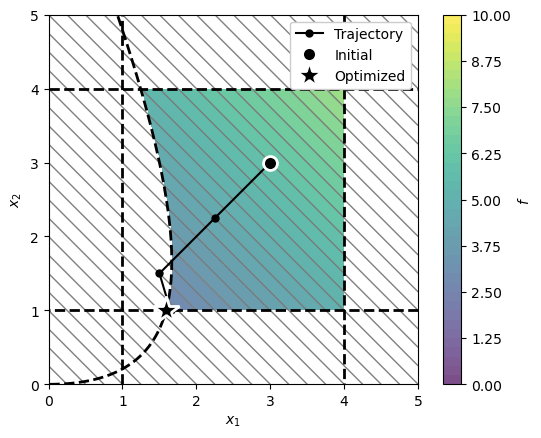

In [2]:
import numpy as np
import matplotlib.pyplot as plt
eps = 1e-12 # ゼロ割り防止用の微小値
x = np.linspace(0.0+eps, 5.0, 400)
y = np.linspace(0.0+eps, 5.0, 400)
X, Y = np.meshgrid(x, y)
Z, _ = objective(np.array([X, Y]))
GI, _ = constraint(np.array([X, Y]))
Cax = -X+x_min[0]
Cay = -Y+x_min[1]
Cbx = X-x_max[0]
Cby = Y-x_max[1]
C1 = GI[0,:]
infeasible_region = (C1 > 0) | (Cax > 0) | (Cay > 0) | (Cbx > 0) | (Cby > 0)
contour = plt.contourf(X, Y, Z, levels=40, cmap="viridis", alpha=0.7)
plt.colorbar(label='$f$')
plt.contourf(X, Y, infeasible_region, levels=[0.5, 1], colors='white', alpha=1.0)
plt.contour(X, Y, Z, levels=40, linestyles='-', linewidths=1, colors='gray', alpha=1)
constraint1 = plt.contour(X, Y, C1, levels=[0], linestyles='--', colors='black', linewidths=2)
constraint_ax = plt.contour(X, Y, Cax, levels=[0], linestyles='--', colors='black', linewidths=2)
constraint_ay = plt.contour(X, Y, Cay, levels=[0], linestyles='--', colors='black', linewidths=2)
constraint_bx = plt.contour(X, Y, Cbx, levels=[0], linestyles='--', colors='black', linewidths=2)
constraint_by = plt.contour(X, Y, Cby, levels=[0], linestyles='--', colors='black', linewidths=2)
trajectory = np.array(trajectory)
plt.plot(trajectory[:, 0], trajectory[:, 1], color='k', marker='.', markersize=10, label="Trajectory")
plt.plot(trajectory[0, 0], trajectory[0, 1], color='k', marker='.', linestyle="", markersize=20, markeredgecolor='w', markeredgewidth=2, label="Initial")  # 開始点
plt.plot(trajectory[-1, 0], trajectory[-1, 1], color='k', marker='*', linestyle="", markersize=20, markeredgecolor='w', markeredgewidth=2, label="Optimized")  # 終了点
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.xticks(np.arange(6))
plt.yticks(np.arange(6))
plt.gca().set_aspect('equal')
plt.legend(framealpha=1)

In [3]:
import numpy as np
from optimizer import SLP as Optimizer
ITR_MAX = 100 # 最大反復回数
X_TOL = 1e-7 # 収束判定のしきい値
x = np.array([3.0, 3.0]) # 初期解
x_min = np.array([1.0, 1.0]) # 側面制約の下限
x_max = np.array([4.0, 4.0]) # 側面制約の上限
m = 1 # 制約関数の数
move_lim = 0.05 # ムーブリミットの上限値
optimizer = Optimizer(x, m, move_lim, x_min, x_max) # 逐次線形計画法のインスタンス
def objective(x):
    f, gradf = x[0]+x[1], np.array([1, 1]) 
    return f, gradf
def constraint(x):
    g1 = 10/(2*x[0]+x[1])-5/(x[0]+2*x[1])-1
    gradg1 = np.array([-20/(2*x[0]+x[1])**2+5/(x[0]+2*x[1])**2, 
                       -10/(2*x[0]+x[1])**2+10/(x[0]+2*x[1])**2])
    gi, gradgi = np.array([g1]), np.array([gradg1])
    return gi, gradgi
trajectory = [x.copy()]
for itr in range(ITR_MAX):
    f, gradf = objective(x)
    gi, gradgi = constraint(x)
    x_new = optimizer.run(itr, x, gi, gradf, gradgi)
    norm_inf_x = np.linalg.norm(x_new-x, np.inf)
    print(f"{itr} iters, x = ({x[0]:.3f}, {x[1]:.3f}), f = {f:.2e}, gi = {gi[0]:.2e}, norm_inf_x = {norm_inf_x:.1e}")
    if norm_inf_x < X_TOL: print('Converged'); break
    x = x_new.copy()
    trajectory.append(x.copy())

0 iters, x = (3.000, 3.000), f = 6.00e+00, gi = -4.44e-01, norm_inf_x = 7.5e-02
1 iters, x = (2.925, 2.925), f = 5.85e+00, gi = -4.30e-01, norm_inf_x = 7.5e-02
2 iters, x = (2.850, 2.850), f = 5.70e+00, gi = -4.15e-01, norm_inf_x = 9.0e-02
3 iters, x = (2.760, 2.760), f = 5.52e+00, gi = -3.96e-01, norm_inf_x = 1.1e-01
4 iters, x = (2.652, 2.652), f = 5.30e+00, gi = -3.72e-01, norm_inf_x = 1.3e-01
5 iters, x = (2.522, 2.522), f = 5.04e+00, gi = -3.39e-01, norm_inf_x = 1.5e-01
6 iters, x = (2.372, 2.372), f = 4.74e+00, gi = -2.97e-01, norm_inf_x = 1.5e-01
7 iters, x = (2.222, 2.222), f = 4.44e+00, gi = -2.50e-01, norm_inf_x = 1.5e-01
8 iters, x = (2.072, 2.072), f = 4.14e+00, gi = -1.96e-01, norm_inf_x = 1.5e-01
9 iters, x = (1.922, 1.922), f = 3.84e+00, gi = -1.33e-01, norm_inf_x = 1.5e-01
10 iters, x = (1.772, 1.772), f = 3.54e+00, gi = -5.97e-02, norm_inf_x = 1.5e-01
11 iters, x = (1.660, 1.622), f = 3.28e+00, gi = 3.92e-03, norm_inf_x = 1.5e-01
12 iters, x = (1.665, 1.472), f = 3.14e

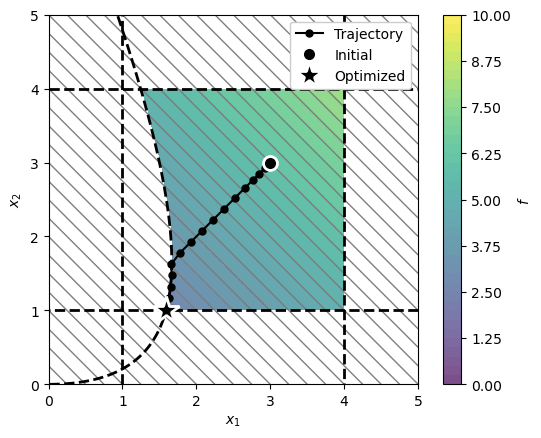

In [4]:
import numpy as np
import matplotlib.pyplot as plt
eps = 1e-12 # ゼロ割り防止用の微小値
x = np.linspace(0.0+eps, 5.0, 400)
y = np.linspace(0.0+eps, 5.0, 400)
X, Y = np.meshgrid(x, y)
Z, _ = objective(np.array([X, Y]))
GI, _ = constraint(np.array([X, Y]))
Cax = -X+x_min[0]
Cay = -Y+x_min[1]
Cbx = X-x_max[0]
Cby = Y-x_max[1]
C1 = GI[0,:]
infeasible_region = (C1 > 0) | (Cax > 0) | (Cay > 0) | (Cbx > 0) | (Cby > 0)
contour = plt.contourf(X, Y, Z, levels=40, cmap="viridis", alpha=0.7)
plt.colorbar(label='$f$')
plt.contourf(X, Y, infeasible_region, levels=[0.5, 1], colors='white', alpha=1.0)
plt.contour(X, Y, Z, levels=40, linestyles='-', linewidths=1, colors='gray', alpha=1)
constraint1 = plt.contour(X, Y, C1, levels=[0], linestyles='--', colors='black', linewidths=2)
constraint_ax = plt.contour(X, Y, Cax, levels=[0], linestyles='--', colors='black', linewidths=2)
constraint_ay = plt.contour(X, Y, Cay, levels=[0], linestyles='--', colors='black', linewidths=2)
constraint_bx = plt.contour(X, Y, Cbx, levels=[0], linestyles='--', colors='black', linewidths=2)
constraint_by = plt.contour(X, Y, Cby, levels=[0], linestyles='--', colors='black', linewidths=2)
trajectory = np.array(trajectory)
plt.plot(trajectory[:, 0], trajectory[:, 1], color='k', marker='.', markersize=10, label="Trajectory")
plt.plot(trajectory[0, 0], trajectory[0, 1], color='k', marker='.', linestyle="", markersize=20, markeredgecolor='w', markeredgewidth=2, label="Initial")  # 開始点
plt.plot(trajectory[-1, 0], trajectory[-1, 1], color='k', marker='*', linestyle="", markersize=20, markeredgecolor='w', markeredgewidth=2, label="Optimized")  # 終了点
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.xticks(np.arange(6))
plt.yticks(np.arange(6))
plt.gca().set_aspect('equal')
plt.legend(framealpha=1)

In [5]:
import numpy as np
from optimizer import SLP as Optimizer
ITR_MAX = 100 # 最大反復回数
X_TOL = 1e-7 # 収束判定のしきい値
x = np.array([3.0, 3.0]) # 初期解
x_min = np.array([1.0, 1.0]) # 側面制約の下限
x_max = np.array([4.0, 4.0]) # 側面制約の上限
m = 2 # 制約関数の数
move_lim = 0.5 # ムーブリミットの上限値
optimizer = Optimizer(x, m, move_lim, x_min, x_max) # 逐次線形計画法のインスタンス
def objective(x):
    f, gradf = x[0]+x[1], np.array([1, 1]) 
    return f, gradf
def constraint(x):
    g1 = 10/(2*x[0]+x[1])-5/(x[0]+2*x[1])-1
    gradg1 = np.array([-20/(2*x[0]+x[1])**2+5/(x[0]+2*x[1])**2, 
                       -10/(2*x[0]+x[1])**2+10/(x[0]+2*x[1])**2])
    g2 = -1*(x[0]-2.0)**2-1*(x[1]-2.5)**2+0.5
    gradg2 = np.array([-2*(x[0]-2.0), -2*(x[1]-2.5)])
    gi, gradgi = np.array([g1, g2]), np.array([gradg1, gradg2])
    return gi, gradgi
trajectory = [x.copy()]
for itr in range(ITR_MAX):
    f, gradf = objective(x)
    gi, gradgi = constraint(x)
    x_new = optimizer.run(itr, x, gi, gradf, gradgi)
    norm_inf_x = np.linalg.norm(x_new-x, np.inf)
    print(f"{itr} iters, x = ({x[0]:.3f}, {x[1]:.3f}), f = {f:.2e}, gi = ({gi[0]:.2e}, {gi[1]:.2e}), norm_inf_x = {norm_inf_x:.1e}")
    if norm_inf_x < X_TOL: print('Converged'); break
    x = x_new.copy()
    trajectory.append(x.copy())

0 iters, x = (3.000, 3.000), f = 6.00e+00, gi = (-4.44e-01, -7.50e-01), norm_inf_x = 7.5e-01
1 iters, x = (3.000, 2.250), f = 5.25e+00, gi = (-4.55e-01, -5.62e-01), norm_inf_x = 7.5e-01
2 iters, x = (2.531, 1.500), f = 4.03e+00, gi = (-3.80e-01, -7.82e-01), norm_inf_x = 9.0e-01
3 iters, x = (1.631, 1.000), f = 2.63e+00, gi = (-3.09e-02, -1.89e+00), norm_inf_x = 4.3e-02
4 iters, x = (1.588, 1.000), f = 2.59e+00, gi = (7.72e-04, -1.92e+00), norm_inf_x = 1.0e-03
5 iters, x = (1.589, 1.000), f = 2.59e+00, gi = (3.82e-07, -1.92e+00), norm_inf_x = 6.0e-07
6 iters, x = (1.589, 1.000), f = 2.59e+00, gi = (-7.57e-08, -1.92e+00), norm_inf_x = 1.9e-13
Converged


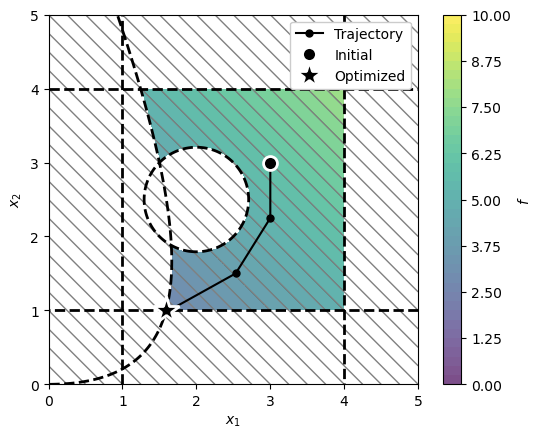

In [6]:
import numpy as np
import matplotlib.pyplot as plt
eps = 1e-12 # ゼロ割り防止用の微小値
x = np.linspace(0.0+eps, 5.0, 400)
y = np.linspace(0.0+eps, 5.0, 400)
X, Y = np.meshgrid(x, y)
Z, _ = objective(np.array([X, Y]))
GI, _ = constraint(np.array([X, Y]))
Cax = -X+x_min[0]
Cay = -Y+x_min[1]
Cbx = X-x_max[0]
Cby = Y-x_max[1]
C1 = GI[0,:]
C2 = GI[1,:]
infeasible_region = (C1 > 0) | (Cax > 0) | (Cay > 0) | (Cbx > 0) | (Cby > 0) | (C2>0)
contour = plt.contourf(X, Y, Z, levels=40, cmap="viridis", alpha=0.7)
plt.colorbar(label='$f$')
plt.contourf(X, Y, infeasible_region, levels=[0.5, 1], colors='white', alpha=1.0)
plt.contour(X, Y, Z, levels=40, linestyles='-', linewidths=1, colors='gray', alpha=1)
constraint1 = plt.contour(X, Y, C1, levels=[0], linestyles='--', colors='black', linewidths=2)
constraint_ax = plt.contour(X, Y, Cax, levels=[0], linestyles='--', colors='black', linewidths=2)
constraint_ay = plt.contour(X, Y, Cay, levels=[0], linestyles='--', colors='black', linewidths=2)
constraint_bx = plt.contour(X, Y, Cbx, levels=[0], linestyles='--', colors='black', linewidths=2)
constraint_by = plt.contour(X, Y, Cby, levels=[0], linestyles='--', colors='black', linewidths=2)
constraint2 = plt.contour(X, Y, C2, levels=[0], linestyles='--', colors='black', linewidths=2)
trajectory = np.array(trajectory)
plt.plot(trajectory[:, 0], trajectory[:, 1], color='k', marker='.', markersize=10, label="Trajectory")
plt.plot(trajectory[0, 0], trajectory[0, 1], color='k', marker='.', linestyle="", markersize=20, markeredgecolor='w', markeredgewidth=2, label="Initial")  # 開始点
plt.plot(trajectory[-1, 0], trajectory[-1, 1], color='k', marker='*', linestyle="", markersize=20, markeredgecolor='w', markeredgewidth=2, label="Optimized")  # 終了点
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.xticks(np.arange(6))
plt.yticks(np.arange(6))
plt.gca().set_aspect('equal')
plt.legend(framealpha=1)

In [7]:
import numpy as np
from optimizer import SLP as Optimizer
ITR_MAX = 100 # 最大反復回数
X_TOL = 1e-7 # 収束判定のしきい値
x = np.array([3.0, 3.0]) # 初期解
x_min = np.array([1.0, 1.0]) # 側面制約の下限
x_max = np.array([4.0, 4.0]) # 側面制約の上限
m = 2 # 制約関数の数
move_lim = 0.05 # ムーブリミットの上限値
optimizer = Optimizer(x, m, move_lim, x_min, x_max) # 逐次線形計画法のインスタンス
def objective(x):
    f, gradf = x[0]+x[1], np.array([1, 1]) 
    return f, gradf
def constraint(x):
    g1 = 10/(2*x[0]+x[1])-5/(x[0]+2*x[1])-1
    gradg1 = np.array([-20/(2*x[0]+x[1])**2+5/(x[0]+2*x[1])**2, 
                        -10/(2*x[0]+x[1])**2+10/(x[0]+2*x[1])**2])
    g2 = -1*(x[0]-2.0)**2-1*(x[1]-2.5)**2+0.5
    gradg2 = np.array([-2*(x[0]-2.0), -2*(x[1]-2.5)])
    gi, gradgi = np.array([g1, g2]), np.array([gradg1, gradg2])
    return gi, gradgi
trajectory = [x.copy()]
for itr in range(ITR_MAX):
    f, gradf = objective(x)
    gi, gradgi = constraint(x)
    x_new = optimizer.run(itr, x, gi, gradf, gradgi)
    norm_inf_x = np.linalg.norm(x_new-x, np.inf)
    print(f"{itr} iters, x = ({x[0]:.3f}, {x[1]:.3f}), f = {f:.2e}, gi = ({gi[0]:.2e}, {gi[1]:.2e}), norm_inf_x = {norm_inf_x:.1e}")
    if norm_inf_x < X_TOL: print('Converged'); break
    x = x_new.copy()
    trajectory.append(x.copy())

0 iters, x = (3.000, 3.000), f = 6.00e+00, gi = (-4.44e-01, -7.50e-01), norm_inf_x = 7.5e-02
1 iters, x = (2.925, 2.925), f = 5.85e+00, gi = (-4.30e-01, -5.36e-01), norm_inf_x = 7.5e-02
2 iters, x = (2.850, 2.850), f = 5.70e+00, gi = (-4.15e-01, -3.45e-01), norm_inf_x = 9.0e-02
3 iters, x = (2.760, 2.760), f = 5.52e+00, gi = (-3.96e-01, -1.45e-01), norm_inf_x = 1.1e-01
4 iters, x = (2.701, 2.652), f = 5.35e+00, gi = (-3.83e-01, -1.51e-02), norm_inf_x = 1.3e-01
5 iters, x = (2.719, 2.522), f = 5.24e+00, gi = (-3.88e-01, -1.71e-02), norm_inf_x = 1.5e-01
6 iters, x = (2.712, 2.372), f = 5.08e+00, gi = (-3.88e-01, -2.26e-02), norm_inf_x = 1.5e-01
7 iters, x = (2.669, 2.222), f = 4.89e+00, gi = (-3.80e-01, -2.43e-02), norm_inf_x = 1.5e-01
8 iters, x = (2.593, 2.072), f = 4.66e+00, gi = (-3.64e-01, -3.40e-02), norm_inf_x = 1.5e-01
9 iters, x = (2.501, 1.922), f = 4.42e+00, gi = (-3.44e-01, -8.48e-02), norm_inf_x = 1.5e-01
10 iters, x = (2.391, 1.772), f = 4.16e+00, gi = (-3.17e-01, -1.83e-01

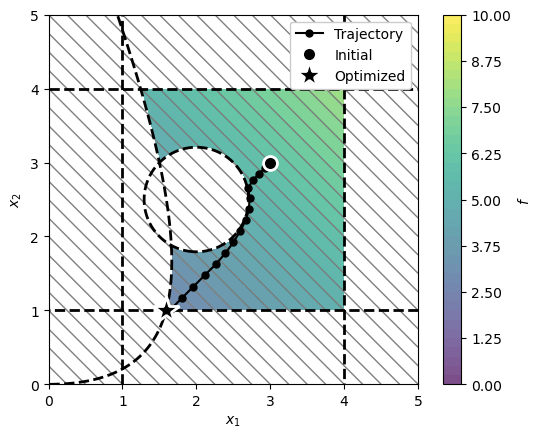

In [8]:
import numpy as np
import matplotlib.pyplot as plt
eps = 1e-12 # ゼロ割り防止用の微小値
x = np.linspace(0.0+eps, 5.0, 400)
y = np.linspace(0.0+eps, 5.0, 400)
X, Y = np.meshgrid(x, y)
Z, _ = objective(np.array([X, Y]))
GI, _ = constraint(np.array([X, Y]))
Cax = -X+x_min[0]
Cay = -Y+x_min[1]
Cbx = X-x_max[0]
Cby = Y-x_max[1]
C1 = GI[0,:]
C2 = GI[1,:]
infeasible_region = (C1 > 0) | (Cax > 0) | (Cay > 0) | (Cbx > 0) | (Cby > 0) | (C2>0)
contour = plt.contourf(X, Y, Z, levels=40, cmap="viridis", alpha=0.7)
plt.colorbar(label='$f$')
plt.contourf(X, Y, infeasible_region, levels=[0.5, 1], colors='white', alpha=1.0)
plt.contour(X, Y, Z, levels=40, linestyles='-', linewidths=1, colors='gray', alpha=1)
constraint1 = plt.contour(X, Y, C1, levels=[0], linestyles='--', colors='black', linewidths=2)
constraint_ax = plt.contour(X, Y, Cax, levels=[0], linestyles='--', colors='black', linewidths=2)
constraint_ay = plt.contour(X, Y, Cay, levels=[0], linestyles='--', colors='black', linewidths=2)
constraint_bx = plt.contour(X, Y, Cbx, levels=[0], linestyles='--', colors='black', linewidths=2)
constraint_by = plt.contour(X, Y, Cby, levels=[0], linestyles='--', colors='black', linewidths=2)
constraint2 = plt.contour(X, Y, C2, levels=[0], linestyles='--', colors='black', linewidths=2)
trajectory = np.array(trajectory)
plt.plot(trajectory[:, 0], trajectory[:, 1], color='k', marker='.', markersize=10, label="Trajectory")
plt.plot(trajectory[0, 0], trajectory[0, 1], color='k', marker='.', linestyle="", markersize=20, markeredgecolor='w', markeredgewidth=2, label="Initial")  # 開始点
plt.plot(trajectory[-1, 0], trajectory[-1, 1], color='k', marker='*', linestyle="", markersize=20, markeredgecolor='w', markeredgewidth=2, label="Optimized")  # 終了点
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.xticks(np.arange(6))
plt.yticks(np.arange(6))
plt.gca().set_aspect('equal')
plt.legend(framealpha=1)

In [9]:
import numpy as np
from optimizer import MMA as Optimizer
ITR_MAX = 100 # 最大反復回数
X_TOL = 1e-7 # 収束判定のしきい値
x = np.array([3.0, 3.0]) # 初期解
x_min = np.array([1.0, 1.0]) # 側面制約の下限
x_max = np.array([4.0, 4.0]) # 側面制約の上限
m = 1 # 制約関数の数
move_lim = 0.5 # ムーブリミットの上限値
optimizer = Optimizer(x, m, move_lim, x_min, x_max) # 逐次線形計画法のインスタンス
def objective(x):
    f, gradf = x[0]+x[1], np.array([1, 1]) 
    return f, gradf
def constraint(x):
    g1 = 10/(2*x[0]+x[1])-5/(x[0]+2*x[1])-1
    gradg1 = np.array([-20/(2*x[0]+x[1])**2+5/(x[0]+2*x[1])**2, 
                       -10/(2*x[0]+x[1])**2+10/(x[0]+2*x[1])**2])
    gi, gradgi = np.array([g1]), np.array([gradg1])
    return gi, gradgi
trajectory = [x.copy()]
for itr in range(ITR_MAX):
    f, gradf = objective(x)
    gi, gradgi = constraint(x)
    x_new = optimizer.run(itr, x, gi, gradf, gradgi)
    norm_inf_x = np.linalg.norm(x_new-x, np.inf)
    print(f"{itr} iters, x = ({x[0]:.3f}, {x[1]:.3f}), f = {f:.2e}, gi = {gi[0]:.2e}, norm_inf_x = {norm_inf_x:.1e}")
    if norm_inf_x < X_TOL: print('Converged'); break
    x = x_new.copy()
    trajectory.append(x.copy())

0 iters, x = (3.000, 3.000), f = 6.00e+00, gi = -4.44e-01, norm_inf_x = 1.3e+00
1 iters, x = (2.077, 1.650), f = 3.73e+00, gi = -2.07e-01, norm_inf_x = 6.5e-01
2 iters, x = (1.677, 1.000), f = 2.68e+00, gi = -6.34e-02, norm_inf_x = 8.8e-02
3 iters, x = (1.589, 1.000), f = 2.59e+00, gi = 1.30e-05, norm_inf_x = 1.7e-05
4 iters, x = (1.589, 1.000), f = 2.59e+00, gi = -7.57e-08, norm_inf_x = 3.7e-11
Converged


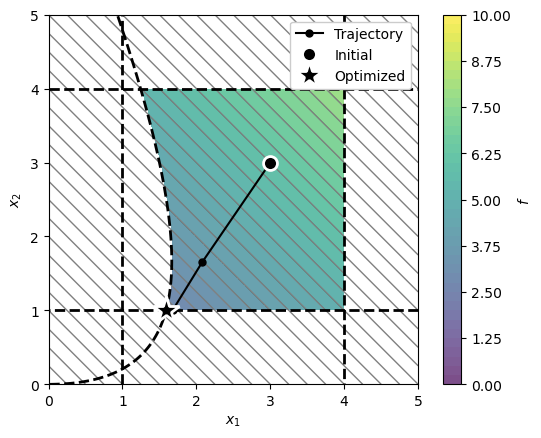

In [10]:
import numpy as np
import matplotlib.pyplot as plt
eps = 1e-12 # ゼロ割り防止用の微小値
x = np.linspace(0.0+eps, 5.0, 400)
y = np.linspace(0.0+eps, 5.0, 400)
X, Y = np.meshgrid(x, y)
Z, _ = objective(np.array([X, Y]))
GI, _ = constraint(np.array([X, Y]))
Cax = -X+x_min[0]
Cay = -Y+x_min[1]
Cbx = X-x_max[0]
Cby = Y-x_max[1]
C1 = GI[0,:]
infeasible_region = (C1 > 0) | (Cax > 0) | (Cay > 0) | (Cbx > 0) | (Cby > 0)
contour = plt.contourf(X, Y, Z, levels=40, cmap="viridis", alpha=0.7)
plt.colorbar(label='$f$')
plt.contourf(X, Y, infeasible_region, levels=[0.5, 1], colors='white', alpha=1.0)
plt.contour(X, Y, Z, levels=40, linestyles='-', linewidths=1, colors='gray', alpha=1)
constraint1 = plt.contour(X, Y, C1, levels=[0], linestyles='--', colors='black', linewidths=2)
constraint_ax = plt.contour(X, Y, Cax, levels=[0], linestyles='--', colors='black', linewidths=2)
constraint_ay = plt.contour(X, Y, Cay, levels=[0], linestyles='--', colors='black', linewidths=2)
constraint_bx = plt.contour(X, Y, Cbx, levels=[0], linestyles='--', colors='black', linewidths=2)
constraint_by = plt.contour(X, Y, Cby, levels=[0], linestyles='--', colors='black', linewidths=2)
trajectory = np.array(trajectory)
plt.plot(trajectory[:, 0], trajectory[:, 1], color='k', marker='.', markersize=10, label="Trajectory")
plt.plot(trajectory[0, 0], trajectory[0, 1], color='k', marker='.', linestyle="", markersize=20, markeredgecolor='w', markeredgewidth=2, label="Initial")  # 開始点
plt.plot(trajectory[-1, 0], trajectory[-1, 1], color='k', marker='*', linestyle="", markersize=20, markeredgecolor='w', markeredgewidth=2, label="Optimized")  # 終了点
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.xticks(np.arange(6))
plt.yticks(np.arange(6))
plt.gca().set_aspect('equal')
plt.legend(framealpha=1)

In [11]:
import numpy as np
from optimizer import MMA as Optimizer
ITR_MAX = 100 # 最大反復回数
X_TOL = 1e-7 # 収束判定のしきい値
x = np.array([3.0, 3.0]) # 初期解
x_min = np.array([1.0, 1.0]) # 側面制約の下限
x_max = np.array([4.0, 4.0]) # 側面制約の上限
m = 1 # 制約関数の数
move_lim = 0.05 # ムーブリミットの上限値
optimizer = Optimizer(x, m, move_lim, x_min, x_max) # 逐次線形計画法のインスタンス
def objective(x):
    f, gradf = x[0]+x[1], np.array([1, 1]) 
    return f, gradf
def constraint(x):
    g1 = 10/(2*x[0]+x[1])-5/(x[0]+2*x[1])-1
    gradg1 = np.array([-20/(2*x[0]+x[1])**2+5/(x[0]+2*x[1])**2, 
                       -10/(2*x[0]+x[1])**2+10/(x[0]+2*x[1])**2])
    gi, gradgi = np.array([g1]), np.array([gradg1])
    return gi, gradgi
trajectory = [x.copy()]
for itr in range(ITR_MAX):
    f, gradf = objective(x)
    gi, gradgi = constraint(x)
    x_new = optimizer.run(itr, x, gi, gradf, gradgi)
    norm_inf_x = np.linalg.norm(x_new-x, np.inf)
    print(f"{itr} iters, x = ({x[0]:.3f}, {x[1]:.3f}), f = {f:.2e}, gi = {gi[0]:.2e}, norm_inf_x = {norm_inf_x:.1e}")
    if norm_inf_x < X_TOL: print('Converged'); break
    x = x_new.copy()
    trajectory.append(x.copy())

0 iters, x = (3.000, 3.000), f = 6.00e+00, gi = -4.44e-01, norm_inf_x = 1.5e-01
1 iters, x = (2.850, 2.850), f = 5.70e+00, gi = -4.15e-01, norm_inf_x = 1.5e-01
2 iters, x = (2.700, 2.700), f = 5.40e+00, gi = -3.83e-01, norm_inf_x = 1.5e-01
3 iters, x = (2.550, 2.550), f = 5.10e+00, gi = -3.46e-01, norm_inf_x = 1.5e-01
4 iters, x = (2.400, 2.400), f = 4.80e+00, gi = -3.06e-01, norm_inf_x = 1.5e-01
5 iters, x = (2.250, 2.250), f = 4.50e+00, gi = -2.59e-01, norm_inf_x = 1.5e-01
6 iters, x = (2.100, 2.100), f = 4.20e+00, gi = -2.06e-01, norm_inf_x = 1.5e-01
7 iters, x = (1.950, 1.950), f = 3.90e+00, gi = -1.45e-01, norm_inf_x = 1.5e-01
8 iters, x = (1.800, 1.800), f = 3.60e+00, gi = -7.41e-02, norm_inf_x = 1.5e-01
9 iters, x = (1.660, 1.650), f = 3.31e+00, gi = 4.16e-03, norm_inf_x = 1.5e-01
10 iters, x = (1.666, 1.500), f = 3.17e+00, gi = -2.19e-03, norm_inf_x = 1.5e-01
11 iters, x = (1.655, 1.350), f = 3.01e+00, gi = -2.49e-03, norm_inf_x = 1.5e-01
12 iters, x = (1.637, 1.200), f = 2.84e

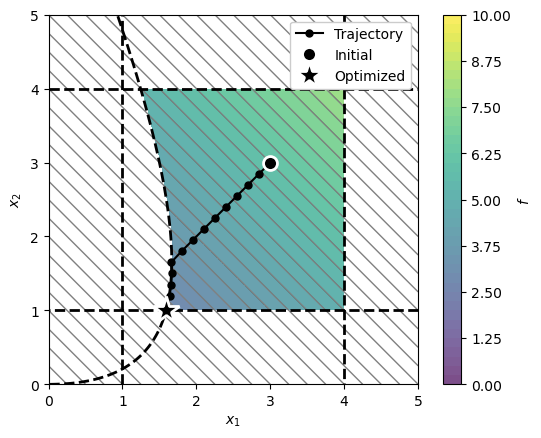

In [12]:
import numpy as np
import matplotlib.pyplot as plt
eps = 1e-12 # ゼロ割り防止用の微小値
x = np.linspace(0.0+eps, 5.0, 400)
y = np.linspace(0.0+eps, 5.0, 400)
X, Y = np.meshgrid(x, y)
Z, _ = objective(np.array([X, Y]))
GI, _ = constraint(np.array([X, Y]))
Cax = -X+x_min[0]
Cay = -Y+x_min[1]
Cbx = X-x_max[0]
Cby = Y-x_max[1]
C1 = GI[0,:]
infeasible_region = (C1 > 0) | (Cax > 0) | (Cay > 0) | (Cbx > 0) | (Cby > 0)
contour = plt.contourf(X, Y, Z, levels=40, cmap="viridis", alpha=0.7)
plt.colorbar(label='$f$')
plt.contourf(X, Y, infeasible_region, levels=[0.5, 1], colors='white', alpha=1.0)
plt.contour(X, Y, Z, levels=40, linestyles='-', linewidths=1, colors='gray', alpha=1)
constraint1 = plt.contour(X, Y, C1, levels=[0], linestyles='--', colors='black', linewidths=2)
constraint_ax = plt.contour(X, Y, Cax, levels=[0], linestyles='--', colors='black', linewidths=2)
constraint_ay = plt.contour(X, Y, Cay, levels=[0], linestyles='--', colors='black', linewidths=2)
constraint_bx = plt.contour(X, Y, Cbx, levels=[0], linestyles='--', colors='black', linewidths=2)
constraint_by = plt.contour(X, Y, Cby, levels=[0], linestyles='--', colors='black', linewidths=2)
trajectory = np.array(trajectory)
plt.plot(trajectory[:, 0], trajectory[:, 1], color='k', marker='.', markersize=10, label="Trajectory")
plt.plot(trajectory[0, 0], trajectory[0, 1], color='k', marker='.', linestyle="", markersize=20, markeredgecolor='w', markeredgewidth=2, label="Initial")  # 開始点
plt.plot(trajectory[-1, 0], trajectory[-1, 1], color='k', marker='*', linestyle="", markersize=20, markeredgecolor='w', markeredgewidth=2, label="Optimized")  # 終了点
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.xticks(np.arange(6))
plt.yticks(np.arange(6))
plt.gca().set_aspect('equal')
plt.legend(framealpha=1)

In [13]:
import numpy as np
from optimizer import MMA as Optimizer
ITR_MAX = 100 # 最大反復回数
X_TOL = 1e-7 # 収束判定のしきい値
x = np.array([3.0, 3.0]) # 初期解
x_min = np.array([1.0, 1.0]) # 側面制約の下限
x_max = np.array([4.0, 4.0]) # 側面制約の上限
m = 2 # 制約関数の数
move_lim = 0.5 # ムーブリミットの上限値
optimizer = Optimizer(x, m, move_lim, x_min, x_max) # 逐次線形計画法のインスタンス
def objective(x):
    f, gradf = x[0]+x[1], np.array([1, 1]) 
    return f, gradf
def constraint(x):
    g1 = 10/(2*x[0]+x[1])-5/(x[0]+2*x[1])-1
    gradg1 = np.array([-20/(2*x[0]+x[1])**2+5/(x[0]+2*x[1])**2, 
                        -10/(2*x[0]+x[1])**2+10/(x[0]+2*x[1])**2])
    g2 = -1*(x[0]-2.0)**2-1*(x[1]-2.5)**2+0.5
    gradg2 = np.array([-2*(x[0]-2.0), -2*(x[1]-2.5)])
    gi, gradgi = np.array([g1, g2]), np.array([gradg1, gradg2])
    return gi, gradgi
trajectory = [x.copy()]
for itr in range(ITR_MAX):
    f, gradf = objective(x)
    gi, gradgi = constraint(x)
    x_new = optimizer.run(itr, x, gi, gradf, gradgi)
    norm_inf_x = np.linalg.norm(x_new-x, np.inf)
    print(f"{itr} iters, x = ({x[0]:.3f}, {x[1]:.3f}), f = {f:.2e}, gi = ({gi[0]:.2e}, {gi[1]:.2e}), norm_inf_x = {norm_inf_x:.1e}")
    if norm_inf_x < X_TOL: print('Converged'); break
    x = x_new.copy()
    trajectory.append(x.copy())

0 iters, x = (3.000, 3.000), f = 6.00e+00, gi = (-4.44e-01, -7.50e-01), norm_inf_x = 3.7e-01
1 iters, x = (2.881, 2.629), f = 5.51e+00, gi = (-4.23e-01, -2.93e-01), norm_inf_x = 6.6e-01
2 iters, x = (2.889, 1.968), f = 4.86e+00, gi = (-4.41e-01, -5.72e-01), norm_inf_x = 9.7e-01
3 iters, x = (2.469, 1.000), f = 3.47e+00, gi = (-4.35e-01, -1.97e+00), norm_inf_x = 4.8e-01
4 iters, x = (1.990, 1.000), f = 2.99e+00, gi = (-2.45e-01, -1.75e+00), norm_inf_x = 3.2e-01
5 iters, x = (1.672, 1.000), f = 2.67e+00, gi = (-5.96e-02, -1.86e+00), norm_inf_x = 8.0e-02
6 iters, x = (1.592, 1.000), f = 2.59e+00, gi = (-1.92e-03, -1.92e+00), norm_inf_x = 2.5e-03
7 iters, x = (1.589, 1.000), f = 2.59e+00, gi = (-1.09e-06, -1.92e+00), norm_inf_x = 1.3e-06
8 iters, x = (1.589, 1.000), f = 2.59e+00, gi = (-7.57e-08, -1.92e+00), norm_inf_x = 7.1e-13
Converged


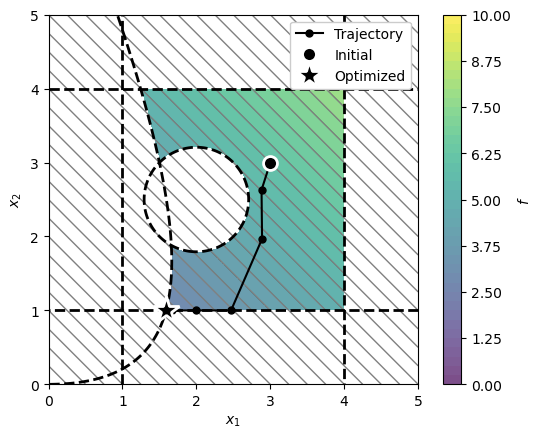

In [14]:
import numpy as np
import matplotlib.pyplot as plt
eps = 1e-12 # ゼロ割り防止用の微小値
x = np.linspace(0.0+eps, 5.0, 400)
y = np.linspace(0.0+eps, 5.0, 400)
X, Y = np.meshgrid(x, y)
Z, _ = objective(np.array([X, Y]))
GI, _ = constraint(np.array([X, Y]))
Cax = -X+x_min[0]
Cay = -Y+x_min[1]
Cbx = X-x_max[0]
Cby = Y-x_max[1]
C1 = GI[0,:]
C2 = GI[1,:]
infeasible_region = (C1 > 0) | (Cax > 0) | (Cay > 0) | (Cbx > 0) | (Cby > 0) | (C2>0)
contour = plt.contourf(X, Y, Z, levels=40, cmap="viridis", alpha=0.7)
plt.colorbar(label='$f$')
plt.contourf(X, Y, infeasible_region, levels=[0.5, 1], colors='white', alpha=1.0)
plt.contour(X, Y, Z, levels=40, linestyles='-', linewidths=1, colors='gray', alpha=1)
constraint1 = plt.contour(X, Y, C1, levels=[0], linestyles='--', colors='black', linewidths=2)
constraint_ax = plt.contour(X, Y, Cax, levels=[0], linestyles='--', colors='black', linewidths=2)
constraint_ay = plt.contour(X, Y, Cay, levels=[0], linestyles='--', colors='black', linewidths=2)
constraint_bx = plt.contour(X, Y, Cbx, levels=[0], linestyles='--', colors='black', linewidths=2)
constraint_by = plt.contour(X, Y, Cby, levels=[0], linestyles='--', colors='black', linewidths=2)
constraint2 = plt.contour(X, Y, C2, levels=[0], linestyles='--', colors='black', linewidths=2)
trajectory = np.array(trajectory)
plt.plot(trajectory[:, 0], trajectory[:, 1], color='k', marker='.', markersize=10, label="Trajectory")
plt.plot(trajectory[0, 0], trajectory[0, 1], color='k', marker='.', linestyle="", markersize=20, markeredgecolor='w', markeredgewidth=2, label="Initial")  # 開始点
plt.plot(trajectory[-1, 0], trajectory[-1, 1], color='k', marker='*', linestyle="", markersize=20, markeredgecolor='w', markeredgewidth=2, label="Optimized")  # 終了点
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.xticks(np.arange(6))
plt.yticks(np.arange(6))
plt.gca().set_aspect('equal')
plt.legend(framealpha=1)

In [15]:
import numpy as np
from optimizer import MMA as Optimizer
ITR_MAX = 100 # 最大反復回数
X_TOL = 1e-7 # 収束判定のしきい値
x = np.array([3.0, 3.0]) # 初期解
x_min = np.array([1.0, 1.0]) # 側面制約の下限
x_max = np.array([4.0, 4.0]) # 側面制約の上限
m = 2 # 制約関数の数
move_lim = 0.05 # ムーブリミットの上限値
optimizer = Optimizer(x, m, move_lim, x_min, x_max) # 逐次線形計画法のインスタンス
def objective(x):
    f, gradf = x[0]+x[1], np.array([1, 1]) 
    return f, gradf
def constraint(x):
    g1 = 10/(2*x[0]+x[1])-5/(x[0]+2*x[1])-1
    gradg1 = np.array([-20/(2*x[0]+x[1])**2+5/(x[0]+2*x[1])**2, 
                        -10/(2*x[0]+x[1])**2+10/(x[0]+2*x[1])**2])
    g2 = -1*(x[0]-2.0)**2-1*(x[1]-2.5)**2+0.5
    gradg2 = np.array([-2*(x[0]-2.0), -2*(x[1]-2.5)])
    gi, gradgi = np.array([g1, g2]), np.array([gradg1, gradg2])
    return gi, gradgi
trajectory = [x.copy()]
for itr in range(ITR_MAX):
    f, gradf = objective(x)
    gi, gradgi = constraint(x)
    x_new = optimizer.run(itr, x, gi, gradf, gradgi)
    norm_inf_x = np.linalg.norm(x_new-x, np.inf)
    print(f"{itr} iters, x = ({x[0]:.3f}, {x[1]:.3f}), f = {f:.2e}, gi = ({gi[0]:.2e}, {gi[1]:.2e}), norm_inf_x = {norm_inf_x:.1e}")
    if norm_inf_x < X_TOL: print('Converged'); break
    x = x_new.copy()
    trajectory.append(x.copy())

0 iters, x = (3.000, 3.000), f = 6.00e+00, gi = (-4.44e-01, -7.50e-01), norm_inf_x = 1.5e-01
1 iters, x = (2.850, 2.850), f = 5.70e+00, gi = (-4.15e-01, -3.45e-01), norm_inf_x = 1.5e-01
2 iters, x = (2.727, 2.700), f = 5.43e+00, gi = (-3.89e-01, -6.81e-02), norm_inf_x = 1.5e-01
3 iters, x = (2.725, 2.550), f = 5.27e+00, gi = (-3.89e-01, -2.80e-02), norm_inf_x = 1.5e-01
4 iters, x = (2.717, 2.400), f = 5.12e+00, gi = (-3.89e-01, -2.37e-02), norm_inf_x = 1.5e-01
5 iters, x = (2.681, 2.250), f = 4.93e+00, gi = (-3.83e-01, -2.61e-02), norm_inf_x = 1.5e-01
6 iters, x = (2.611, 2.100), f = 4.71e+00, gi = (-3.68e-01, -3.31e-02), norm_inf_x = 1.5e-01
7 iters, x = (2.493, 1.950), f = 4.44e+00, gi = (-3.40e-01, -4.57e-02), norm_inf_x = 1.5e-01
8 iters, x = (2.343, 1.800), f = 4.14e+00, gi = (-3.00e-01, -1.08e-01), norm_inf_x = 1.5e-01
9 iters, x = (2.193, 1.650), f = 3.84e+00, gi = (-2.54e-01, -2.60e-01), norm_inf_x = 1.5e-01
10 iters, x = (2.043, 1.500), f = 3.54e+00, gi = (-2.01e-01, -5.02e-01

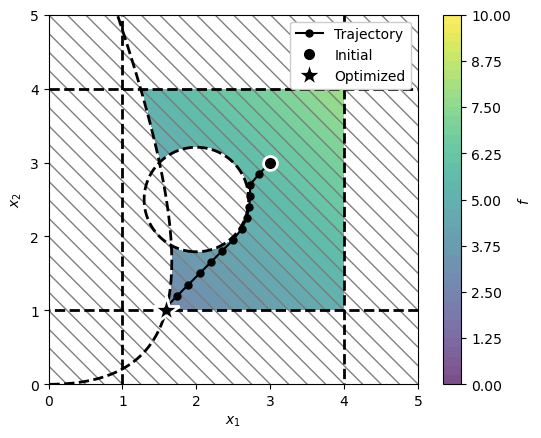

In [16]:
import numpy as np
import matplotlib.pyplot as plt
eps = 1e-12 # ゼロ割り防止用の微小値
x = np.linspace(0.0+eps, 5.0, 400)
y = np.linspace(0.0+eps, 5.0, 400)
X, Y = np.meshgrid(x, y)
Z, _ = objective(np.array([X, Y]))
GI, _ = constraint(np.array([X, Y]))
Cax = -X+x_min[0]
Cay = -Y+x_min[1]
Cbx = X-x_max[0]
Cby = Y-x_max[1]
C1 = GI[0,:]
C2 = GI[1,:]
infeasible_region = (C1 > 0) | (Cax > 0) | (Cay > 0) | (Cbx > 0) | (Cby > 0) | (C2>0)
contour = plt.contourf(X, Y, Z, levels=40, cmap="viridis", alpha=0.7)
plt.colorbar(label='$f$')
plt.contourf(X, Y, infeasible_region, levels=[0.5, 1], colors='white', alpha=1.0)
plt.contour(X, Y, Z, levels=40, linestyles='-', linewidths=1, colors='gray', alpha=1)
constraint1 = plt.contour(X, Y, C1, levels=[0], linestyles='--', colors='black', linewidths=2)
constraint_ax = plt.contour(X, Y, Cax, levels=[0], linestyles='--', colors='black', linewidths=2)
constraint_ay = plt.contour(X, Y, Cay, levels=[0], linestyles='--', colors='black', linewidths=2)
constraint_bx = plt.contour(X, Y, Cbx, levels=[0], linestyles='--', colors='black', linewidths=2)
constraint_by = plt.contour(X, Y, Cby, levels=[0], linestyles='--', colors='black', linewidths=2)
constraint2 = plt.contour(X, Y, C2, levels=[0], linestyles='--', colors='black', linewidths=2)
trajectory = np.array(trajectory)
plt.plot(trajectory[:, 0], trajectory[:, 1], color='k', marker='.', markersize=10, label="Trajectory")
plt.plot(trajectory[0, 0], trajectory[0, 1], color='k', marker='.', linestyle="", markersize=20, markeredgecolor='w', markeredgewidth=2, label="Initial")  # 開始点
plt.plot(trajectory[-1, 0], trajectory[-1, 1], color='k', marker='*', linestyle="", markersize=20, markeredgecolor='w', markeredgewidth=2, label="Optimized")  # 終了点
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.xticks(np.arange(6))
plt.yticks(np.arange(6))
plt.gca().set_aspect('equal')
plt.legend(framealpha=1)